# **Facial Emotion Detection**


## **About the dataset**

The data set consists of 3 folders, 'test', 'train', and 'validation'.
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


In [ ]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Importing the Libraries**

In [ ]:
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

# Importing Deep Learning Libraries

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Input, Dropout, GlobalAveragePooling2D, Flatten, Conv2D, BatchNormalization, Activation, MaxPooling2D, LeakyReLU
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

### **Load the data**

In [ ]:
# Storing the path of the data file from the Google drive
path = '/content/drive/MyDrive/Facial_emotion_images.zip'

# The data is provided as a zip file so we need to extract the files from the zip file
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
picture_size = 48
folder_path = "Facial_emotion_images/"

### **Happy**

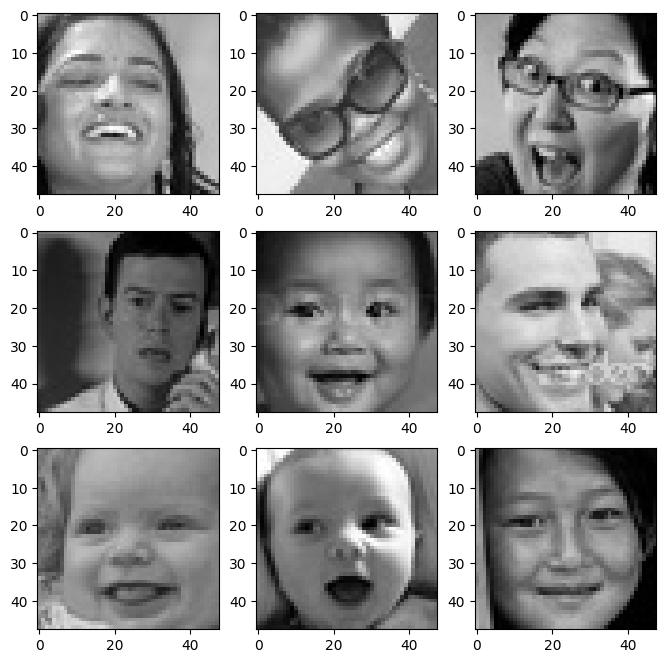

In [ ]:
expression = 'happy'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

### **Sad**

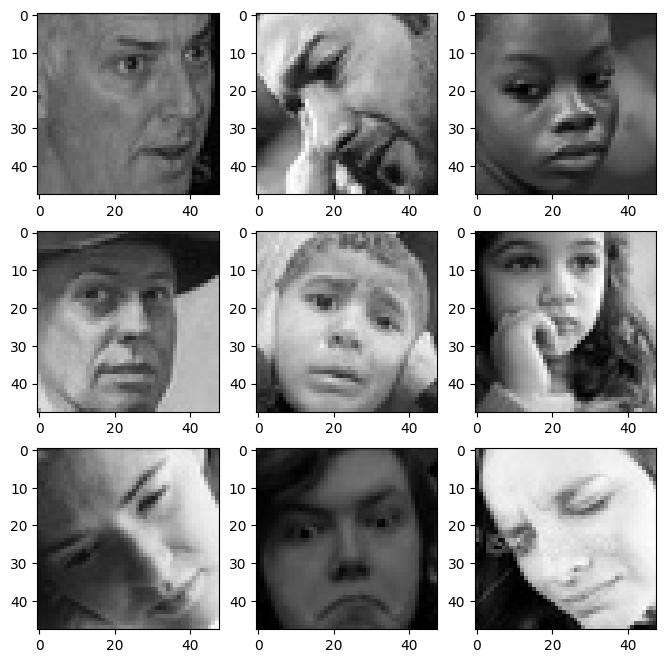

In [ ]:
expression = 'sad'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

In [ ]:
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array
import cv2
import os

# Load the pre-trained model (e.g., VGG16)
base_model = VGG16(weights='imagenet')
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc1').output)

# Define a function to extract features from the image
def extract_features(image):
    # Resize the image to 224x224 pixels, as required by VGG16
    image = cv2.resize(image, (224, 224))
    # Convert the image to array
    image = img_to_array(image)
    # Expand dimensions to match the input shape of the model
    image = np.expand_dims(image, axis=0)
    # Preprocess the image (as VGG16 requires)
    image = preprocess_input(image)
    # Extract features using the model
    features = model.predict(image)
    return features

# Function to predict Big Five personality traits (a placeholder - this model needs training)
def predict_personality(features):
    # You would need a trained model to predict the personality traits based on features
    # Here we simulate prediction for demonstration purposes.
    personality_traits = {
        "Openness": np.random.uniform(0, 1),
        "Conscientiousness": np.random.uniform(0, 1),
        "Extraversion": np.random.uniform(0, 1),
        "Agreeableness": np.random.uniform(0, 1),
        "Neuroticism": np.random.uniform(0, 1)
    }
    return personality_traits

# Function to extract and load images from the zip file
def load_images_from_zip(zip_file_path, extract_to="extracted_images"):
    # Create a folder to extract images
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)

    # Extract the zip file
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    # Collect all image file paths from the extracted folder
    image_paths = []
    for root, dirs, files in os.walk(extract_to):
        for file in files:
            if file.endswith(('.png', '.jpg', '.jpeg')):  # Ensure only image files are picked
                image_paths.append(os.path.join(root, file))

    return image_paths

# Main function to process images and predict personality traits
def process_images_and_predict_personality(zip_file_path):
    # Load image paths from the zip file
    image_paths = load_images_from_zip(zip_file_path)

    # Loop over each image
    for i, image_path in enumerate(image_paths):
        # Load the image using OpenCV
        img = cv2.imread(image_path)

        if img is None:
            print(f"Unable to load image {image_path}. Skipping.")
            continue

        # Extract features from the image
        features = extract_features(img)

        # Predict personality traits based on the features
        personality = predict_personality(features)

        print(f"Image {i+1} ({os.path.basename(image_path)}): Personality Traits")
        for trait, value in personality.items():
            print(f"{trait}: {value:.2f}")
        print("\n")

# Path to your .zip file containing the images
zip_file_path = '/content/drive/MyDrive/Facial_emotion_images.zip'  # Replace with your actual .zip file path

# Process the images and predict personality traits
process_images_and_predict_personality(zip_file_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Image 1 (6939.jpg): Personality Traits
Openness: 0.50
Conscientiousness: 0.22
Extraversion: 0.89
Agreeableness: 0.52
Neuroticism: 0.76


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step
Image 2 (6866.jpg): Personality Traits
Openness: 0.11
Conscientiousness: 0.24
Extraversion: 0.76
Agreeableness: 0.60
Neuroticism: 0.08


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
Image 3 (6858.jpg): Personality Traits
Openness: 0.79
Conscientiousness: 0.02
Extraversion: 0.02
Agreeableness: 0.82
Neuroticism: 0.74


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
Image 4 (6832.jpg): Personality Traits
Openness: 0.45
Conscientiousness: 0.31
Extraversion: 0.85
Agreeableness: 0.10
Neuroticism: 0.06


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step
Image 5 (6871.jpg): Personality Traits
Openness: 0.77
Conscientiousness: 0.24
Extraversion: 0.13
Agreeableness: 0.49
Neuroticism: 0.21


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step
Image 6 (7000.jpg): Personality Traits
Openness: 0.22
Conscientiousness: 0.16
Extrav

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Image 372 (19135.jpg): Personality Traits
Openness: 0.16
Conscientiousness: 0.08
Extraversion: 0.65
Agreeableness: 0.65
Neuroticism: 0.77


Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-13-b627505cdf69>", line 89, in <cell line: 89>
    process_images_and_predict_personality(zip_file_path)
  File "<ipython-input-13-b627505cdf69>", line 75, in process_images_and_predict_personality
    features = extract_features(img)
  File "<ipython-input-13-b627505cdf69>", line 25, in extract_features
    features = model.predict(image)
  File "/usr/local/lib/python3.10/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/keras/src/backend/tensorflow/trainer.py", line 446, in predict
    epoch_iterator = TFEpochIterator(
  File "

TypeError: object of type 'NoneType' has no len()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Function to calculate RIASEC score based on user variables
def calculate_riasec_score(user_data):
   

    # Initialize scores for each RIASEC trait
    R, I, A, S, E, C = 0, 0, 0, 0, 0, 0

    # 1. Realistic (R) - The 'Do-er'
    if 'bidder_hourly_rate' in user_data:
        R += user_data['bidder_hourly_rate'] * 0.3
    if 'bidder_completion_rate' in user_data:
        R += user_data['bidder_completion_rate'] * 0.5
    if 'bidder_total_projects' in user_data:
        R += user_data['bidder_total_projects'] * 0.2

    # 2. Investigative (I) - The 'Thinker'
    if 'bidder_description' in user_data:
        I += len(user_data['bidder_description'].split()) * 0.1
    if 'bidder_qualifications_formatted' in user_data:
        I += len(user_data['bidder_qualifications_formatted']) * 0.3

    # 3. Artistic (A) - The 'Creator'
    if 'bidder_portfolio_count' in user_data:
        A += user_data['bidder_portfolio_count'] * 0.4
    if 'bidder_description' in user_data and 'art' in user_data['bidder_description'].lower():
        A += 1.0

    # 4. Social (S) - The 'Helper'
    if 'bidder_reviews' in user_data:
        S += user_data['bidder_reviews'] * 0.4
    if 'bidder_recommendations' in user_data:
        # Check if bidder_recommendations is a list, otherwise handle it appropriately
        if isinstance(user_data['bidder_recommendations'], list):
            S += len(user_data['bidder_recommendations']) * 0.3
        elif pd.notnull(user_data['bidder_recommendations']):  # In case it's a number or other type
            S += user_data['bidder_recommendations'] * 0.3

    # 5. Enterprising (E) - The 'Persuader'
    if 'bidder_profile_verified' in user_data and user_data['bidder_profile_verified']:
        E += 1.0
    if 'bidder_rating' in user_data:
        E += user_data['bidder_rating'] * 0.5

    # 6. Conventional (C) - The 'Organizer'
    if 'bidder_on_budget' in user_data:
        C += user_data['bidder_on_budget'] * 0.4
    if 'bidder_on_time' in user_data:
        C += user_data['bidder_on_time'] * 0.4

    # Handle NaN values before normalization
    scores = np.array([[R, I, A, S, E, C]])

    # Replace NaN values with 0 (or you can choose to impute with the mean or other values)
    scores = np.nan_to_num(scores)

    # Normalize the scores
    scaler = MinMaxScaler()
    normalized_scores = scaler.fit_transform(scores)[0]

    # Return the scores in a dictionary
    riasec_scores = {
        'Realistic (R)': normalized_scores[0],
        'Investigative (I)': normalized_scores[1],
        'Artistic (A)': normalized_scores[2],
        'Social (S)': normalized_scores[3],
        'Enterprising (E)': normalized_scores[4],
        'Conventional (C)': normalized_scores[5]
    }

    return riasec_scores

# Load the user data from Excel file
#df = pd.read_excel('/content/drive/MyDrive/Final_Version27082024.xlsx')

# Remove any duplicate bidder IDs to ensure uniqueness
df = df.drop_duplicates(subset='bidder_id')

# Extract the unique list of bidder IDs
unique_bidder_ids = df['bidder_id'].to_list()

# List to hold the RIASEC results for each user
riasec_results = []

# Loop through each user and calculate the RIASEC score
for user_id in unique_bidder_ids:
    # Extract user data from the dataframe for the given user_id
    user_data = df[df['bidder_id'] == user_id].iloc[0].to_dict()

    # Calculate RIASEC scores for the current user
    riasec_scores = calculate_riasec_score(user_data)

    # Append the results to the list
    riasec_results.append({
        'bidder_id': user_id,
        **riasec_scores
    })

# Convert the results into a DataFrame for better visualization
riasec_df = pd.DataFrame(riasec_results)

# Display the RIASEC scores
print(riasec_df)

# Save the results to a new Excel file (optional)
riasec_df.to_excel('/content/drive/MyDrive/RIASEC_Scores.xlsx', index=False)


      bidder_id  Realistic (R)  Investigative (I)  Artistic (A)  Social (S)  \
0       7852747            0.0                0.0           0.0         0.0   
1      64643109            0.0                0.0           0.0         0.0   
2      11911076            0.0                0.0           0.0         0.0   
3      14215928            0.0                0.0           0.0         0.0   
4      26340018            0.0                0.0           0.0         0.0   
...         ...            ...                ...           ...         ...   
2470   78582466            0.0                0.0           0.0         0.0   
2471   78569385            0.0                0.0           0.0         0.0   
2472   77497707            0.0                0.0           0.0         0.0   
2473   78550420            0.0                0.0           0.0         0.0   
2474   78569235            0.0                0.0           0.0         0.0   

      Enterprising (E)  Conventional (C)  
0       

In [ ]:


# List all folders (classes) in the base directory
classes = ['happy', 'sad', 'surprise', 'neutral']

# Define the number of images to display per class
num_images_to_display = 5

# Loop through each class
for class_name in classes:
    # Path to the folder for the current class
    class_dir = os.path.join(base_dir, class_name)

    # List all images in the current class directory
   image_files = os.listdir(class_dir)

    # Display the first few images for the current class
    print(f"Displaying images for class: {class_name}")
    for i in range(num_images_to_display):
        # Path to the current image
        img_path = os.path.join(class_dir, image_files[i])

        # Read image using OpenCV
        img = cv2.imread(img_path)

        # Convert image from BGR to RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display image
        plt.imshow(img_rgb)
        plt.title(f'{class_name} Image')
        plt.axis('off')  # Hide axis
        plt.show()


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 13)

**Observations and Insights:__**

### **Neutral**

In [ ]:
# Code to visualize images from the class 'neutral'.

### **Surprised**

In [ ]:
# Code to visualize images from the class 'surprise'.

## **Checking Distribution of Classes**

In [ ]:
# Getting count of images in each folder within our training path
num_happy = len(os.listdir(folder_path + "train/happy"))
print("Number of images in the class 'happy':   ", num_happy)

num_sad = # Write the code to get the number of training images from the class 'sad'.

num_neutral = # Write the code to get the number of training images from the class 'neutral'.

num_surprise = # Write the code to get the number of training images from the class 'surprise'.

In [ ]:
# Code to plot histogram
plt.figure(figsize = (10, 5))

data = {'Happy': num_happy, 'Sad': num_sad, 'Neutral': num_neutral, 'Surprise' : num_surprise}

df = pd.Series(data)

plt.bar(range(len(df)), df.values, align = 'center')

plt.xticks(range(len(df)), df.index.values, size = 'small')

plt.show()

## **Creating our Data Loaders**



In [ ]:
batch_size  = 32
img_size = 48

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = # Provide your chosen color_mode here ,
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)


datagen_validation = # Write your code here

validation_set = # Write your code here


datagen_test = # Write your code here

test_set = # Write your code here

## **Model Building**

### **Creating the Base Neural Network**

Our Base Neural network will be a fairly simple model architecture.

* We want our Base Neural Network architecture to have 3 convolutional blocks.
* Each convolutional block must contain one Conv2D layer followed by a maxpooling layer and one Dropout layer. We can play around with the dropout ratio.
* Add first Conv2D layer with **64 filters** and a **kernel size of 2**. Use the 'same' padding and provide the **input_shape = (48, 48, 3) if you are using 'rgb' color mode in your dataloader or else input shape = (48, 48, 1) if you're using 'grayscale' colormode**. Use **'relu' activation**.
* Add MaxPooling2D layer with **pool size = 2**.
* Add a Dropout layer with a dropout ratio of 0.2.
* Add a second Conv2D layer with **32 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.**
* Follow this up with a similar Maxpooling2D layer like above and a Dropout layer with 0.2 Dropout ratio to complete your second Convolutional Block.
* Add a third Conv2D layer with **32 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.** Once again, follow it up with a Maxpooling2D layer and a Dropout layer to complete your third Convolutional block.
* After adding your convolutional blocks, add your Flatten layer.
* Add your first Dense layer with **512 neurons**. Use **'relu' activation function**.
* Add a Dropout layer with dropout ratio of 0.4.
* Add your final Dense Layer with 4 neurons and **'softmax' activation function**
* Print your model summary

In [ ]:
# Initializing a Sequential Model
model1 = Sequential()

# Add the first Convolutional block

# Add the second Convolutional block

# Add the third Convolutional block

# Add the Flatten layer

# Add the first Dense layer

# Add the Final layer

model1.summary()

### **Compiling and Training the Model**

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./model1.h5", monitor='val_acc', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

epochs = 20

In [ ]:
# Code to compile your model1. Use categorical crossentropy as your loss function, Adam Optimizer with 0.001 learning rate, and set your metrics to 'accuracy'.

In [ ]:
# Code to fit your model1. Use train_set as your training data and validation_set as your validation data. Train your model for 20 epochs.

history = model1.fit(_________)

### **Evaluating the Model on the Test Set**

In [ ]:
# Code to evaluate your model on test data.

### **Creating the second Convolutional Neural Network**

In the second Neural network, we will add a few more Convolutional blocks. We will also use Batch Normalization layers.

* This time, each Convolutional block will have 1 Conv2D layer, followed by a BatchNormalization, LeakuRelU, and a MaxPooling2D layer. We are not adding any Dropout layer this time.
* Add first Conv2D layer with **256 filters** and a **kernel size of 2**. Use the 'same' padding and provide the **input_shape = (48, 48, 3) if you are using 'rgb' color mode in your dataloader or else input shape = (48, 48, 1) if you're using 'grayscale' colormode**. Use **'relu' activation**.
* Add your BatchNormalization layer followed by a LeakyRelU layer with Leaky ReLU parameter of **0.1**
* Add MaxPooling2D layer with **pool size = 2**.
* Add a second Conv2D layer with **128 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.**
* Follow this up with a similar BatchNormalization, LeakyRelU, and Maxpooling2D layer like above to complete your second Convolutional Block.
* Add a third Conv2D layer with **64 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.** Once again, follow it up with a BatchNormalization, LeakyRelU, and Maxpooling2D layer to complete your third Convolutional block.
* Add a fourth block, with the Conv2D layer having **32 filters**.
* After adding your convolutional blocks, add your Flatten layer.
* Add your first Dense layer with **512 neurons**. Use **'relu' activation function**.
* Add the second Dense Layer with **128 neurons** and use **'relu' activation** function.
* Add your final Dense Layer with 4 neurons and **'softmax' activation function**
* Print your model summary

In [ ]:
# Creating sequential model
model2 = Sequential()

# Add the first Convolutional block

# Add the second Convolutional block

# Add the third Convolutional block

# Add the fourth Convolutional block

# Add the Flatten layer

# Adding the Dense layers

model2.summary()

### **Compiling and Training the Model**



In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./model2.h5", monitor='val_loss', verbose = 1, save_best_only = True, mode = 'max')

early_stopping = ________ 
reduce_learningrate = _________ 
callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

epochs = 20

In [ ]:
# Compile your model2. Categorical crossentropy as the loss function, Adam Optimizer with 0.001 learning rate, and set metrics as 'accuracy'.

In [ ]:
history = # Code to fit your model2. train_set as the training data and validation_set as the validation data. Train your model for 20 epochs.

### **Evaluating the Model on the Test Set**

In [ ]:
# Code to evaluate model's test performance

## **Transfer Learning Architectures**



### **Creating our Data Loaders for Transfer Learning Architectures**



In [ ]:
batch_size  = 32
img_size = 48

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range = (0., 2.),
                                    rescale = 1./255,
                                    shear_range = 0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)

datagen_validation = #Code

validation_set = # 

datagen_test = # 

test_set = # 

## **VGG16 Model**

### **Importing the VGG16 Architecture**

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import Model

vgg = VGG16(include_top = False, weights = 'imagenet', input_shape = (48, 48, 3))
vgg.summary()

### **Model Building**

* In this model, we will import till the **'block5_pool'** layer of the VGG16 model. You can scroll down in the model summary and look for 'block5_pool'. Choose any other layer as well.
* Then we will add a Flatten layer, which receives the output of the 'block5_pool' layer as its input.
* We will add a few Dense layers and use 'relu' activation function on them.
* You may use Dropout and BatchNormalization layers as well.
* Then we will add our last dense layer, which must have 4 neurons and a 'softmax' activation function.

In [ ]:
transfer_layer = vgg.get_layer('block5_pool')
vgg.trainable = False

# Add classification layers on top of it
____________

# Flattenning the output from the 3rd block of the VGG16 model
x = Flatten()(transfer_layer.output)

# Adding a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Dense Layer with 128 neurons
____________

# Add a DropOut layer with Drop out ratio of 0.3
____________

# Add a Dense Layer with 64 neurons
____________

# Add a Batch Normalization layer
____________

# Adding the final dense layer with 4 neurons and use 'softmax' activation
pred = Dense(4, activation='softmax')(x)

vggmodel = Model(vgg.input, pred) # Initializing the model

### **Compiling and Training the VGG16 Model**

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./vggmodel.h5", monitor = 'val_loss', verbose = 1, save_best_only = True, mode = 'max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

epochs = 20

In [ ]:
# Code to compile the vggmodel. Use categorical crossentropy as the loss function, Adam Optimizer with 0.001 learning rate, and set metrics to 'accuracy'.

In [ ]:
history = # Code to fit your model. Use train_set as the training data and validation_set as the validation data. Train the model for 20 epochs.


### **Evaluating the VGG16 model**

In [ ]:
# Code to evaluate model performance on the test set

## **ResNet V2 Model**

In [ ]:
import tensorflow as tf
import tensorflow.keras.applications as ap
from tensorflow.keras import Model

Resnet = ap.ResNet101(include_top = False, weights = "imagenet", input_shape=(48,48,3))
Resnet.summary()

### **Model Building**

* In this model, we will import till the **'conv5_block3_add'** layer of the ResNet model. Scroll down in the model summary and look for 'conv5_block3_add'. You can choose any other layer as well.
* Then we will add a Flatten layer, which receives the output of the 'conv5_block3_add' layer as its input.
* We will add a few Dense layers and use 'relu' activation function on them.
* You may use Dropout and BatchNormalization layers as well.
* Then we will add our last dense layer, which must have 4 neurons and a 'softmax' activation function.

In [ ]:
transfer_layer_Resnet = Resnet.get_layer('conv5_block3_add')
Resnet.trainable=False

# Add classification layers on top of it
____________

# Flattenning the output from the 3rd block of the VGG16 model
x = Flatten()(transfer_layer_Resnet.output)

# Add a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Dense Layer with 128 neurons
____________

# Add a DropOut layer with Drop out ratio of 0.3
____________

# Add a Dense Layer with 64 neurons
____________

# Add a Batch Normalization layer
____________

# Add the final dense layer with 4 neurons and use a 'softmax' activation
pred = Dense(4, activation = 'softmax')(x)

resnetmodel = Model(vgg.input, pred) # Initializing the model

### **Compiling and Training the Model**

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./Resnetmodel.h5", monitor = 'val_acc', verbose = 1, save_best_only = True, mode = 'max')

early_stopping = _________  # Code 


reduce_learningrate = _________ # Code 


callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

epochs = 10

In [ ]:
# Code to compile your resnetmodel. Use categorical crossentropy as your loss function, Adam Optimizer with 0.001 learning rate, and set your metrics to 'accuracy'.

In [ ]:
history = # Code to fit your model. Use train_set as your training data and validation_set as your validation data. Train your model for 20 epochs.


### **Evaluating the ResNet Model**

In [ ]:
# Code to evaluate model performance on the test set

## **EfficientNet Model**

In [ ]:
import tensorflow as tf
import tensorflow.keras.applications as ap
from tensorflow.keras import Model
EfficientNet = ap.EfficientNetV2B2(include_top=False,weights="imagenet", input_shape= (48, 48, 3))

EfficientNet.summary()

### **Model Building**

**Build your own Architecture on top of the transfer layer. Be sure to have a Flatten layer after your transfer layer and also make sure you have 4 neurons and softmax activation function in your last dense layer**

In [ ]:
transfer_layer_EfficientNet = EfficientNet.get_layer('block6e_expand_activation')
EfficientNet.trainable = False

# Add your Flatten layer.
__________

# Add your Dense layers and/or BatchNormalization and Dropout layers
__________

# Add your final Dense layer with 4 neurons and softmax activation function.
__________

Efficientnetmodel = Model(EfficientNet.input, pred)

### **Compiling and Training the Model**

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./Efficientnetmodel.h5", monitor='val_acc', verbose=1, save_best_only=True, mode='max')

early_stopping = _________  # Code here. You may play around with the hyperparameters if you wish.

reduce_learningrate = _________  # Code here. You may play around with the hyperparameters if you wish.

callbacks_list = [early_stopping,checkpoint,reduce_learningrate]

epochs = 10

In [ ]:
# Code to compile your Efficientnetmodel. Use categorical crossentropy as your loss function, Adam Optimizer with 0.001 learning rate, and set your metrics to 'accuracy'.

In [ ]:
history = # Code to fit your model. Use train_set as your training data and validation_set as your validation data. Train your model for 20 epochs.

### **Evaluating the EfficientnetNet Model**

In [ ]:
# Code to evaluate the model performance on the test set

## **Building a Complex Neural Network Architecture**

## **Creating our Data Loaders**

Complicated Convolutional Neural Network. We will go ahead with color_mode = 'grayscale'.

In [ ]:
batch_size  = 32
img_size = 48

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range = (0., 2.),
                                    rescale = 1./255,
                                    shear_range = 0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)


datagen_validation = # Code
validation_set = # 

datagen_test = # 

test_set = # 

### **Model Building**

* In this network, we plan to have 5 Convolutional Blocks
* Add first Conv2D layer with **64 filters** and a **kernel size of 2**. Use the 'same' padding and provide the **input shape = (48, 48, 1)**. Use **'relu' activation**.
* Add your BatchNormalization layer followed by a LeakyRelU layer with Leaky ReLU parameter of **0.1**
* Add MaxPooling2D layer with **pool size = 2**.
* Add a Dropout layer with a Dropout Ratio of **0.2**. This completes the first Convolutional block.
* Add a second Conv2D layer with **128 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.**
* Follow this up with a similar BatchNormalization, LeakyRelU, Maxpooling2D, and Dropout layer like above to complete your second Convolutional Block.
* Add a third Conv2D layer with **512 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.** Once again, follow it up with a BatchNormalization, LeakyRelU, Maxpooling2D, and Dropout layer to complete your third Convolutional block.
* Add a fourth block, with the Conv2D layer having **512 filters**.
* Add the fifth block, having **128 filters**.
* Then add your Flatten layer, followed by your Dense layers.
* Add your first Dense layer with **256 neurons** followed by a BatchNormalization layer, a **'relu'** Activation, and a Dropout layer. This forms your first Fully Connected block
* Add your second Dense layer with **512 neurons**, again followed by a BatchNormalization layer, **relu** activation, and a Dropout layer.
* Add your final Dense layer with 4 neurons.
* Compile your model with the optimizer of your choice.

In [ ]:
no_of_classes = 4

model3 = Sequential()

# Add 1st CNN Block
____________

# Add 2nd CNN Block
____________

# Add 3rd CNN Block
____________

# Add 4th CNN Block
____________

# Add 5th CNN Block
____________

model3.add(Flatten())

# First fully connected layer
____________

# Second fully connected layer
____________

model3.add(Dense(no_of_classes, activation = 'softmax'))

### **Compiling and Training the Model**

In [ ]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger

epochs = 35

steps_per_epoch = train_set.n//train_set.batch_size
validation_steps = validation_set.n//validation_set.batch_size

checkpoint = ModelCheckpoint("model3.h5", monitor = 'val_accuracy',
                            save_weights_only = True, model = 'max', verbose = 1)

reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.1, patience = 2, min_lr = 0.0001 , model = 'auto')

callbacks = [checkpoint, reduce_lr]

In [ ]:
# Code to compile your model3. Use categorical crossentropy as the loss function, Adam Optimizer with 0.003 learning rate, and set metrics to 'accuracy'.

In [ ]:
history = # Code to fit your model. Use train_set as the training data and validation_set as the validation data. Train your model for 35 epochs.

### **Evaluating the Model on Test Set**

In [ ]:
# Code to evaluate the model performance on the test set

### **Plotting the Confusion Matrix for the chosen final model**

In [ ]:
# Plot the confusion matrix and generate a classification report for the model
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
test_set = datagen_test.flow_from_directory(folder_path + "test",
                                                              target_size = (img_size,img_size),
                                                              color_mode = 'grayscale',
                                                              batch_size = 128,
                                                              class_mode = 'categorical',
                                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                                              shuffle = True)
test_images, test_labels = next(test_set)

# Write the name of your chosen model in the blank
pred = ________.predict(test_images)
pred = np.argmax(pred, axis = 1)
y_true = np.argmax(test_labels, axis = 1)

# Printing the classification report
_____________

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ['happy', 'sad', 'neutral', 'surprise'], yticklabels = ['happy', 'sad', 'neutral', 'surprise'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()